# 01_04 · EDA — SPARK TEC Electrical Monitoring

**Dataset**: SPARK — High-Resolution Energy Data from a Sustainable Industrial Production Area in Karlsruhe
**DOI**: 10.35097/bjdg3m3rg5jv3skk
**Máquinas**: 11 máquinas TEC (fresadoras CNC, tornos, EDM) — año 2024
**Resolución original**: 5 segundos · agregado a 1 minuto en este notebook para el análisis

Variables monitorizadas (12 señales):
`P_total, P1, P2, P3` — potencia activa (W) | `I1, I2, I3` — corriente de fase (A)
`Freq` — frecuencia de red (Hz) | `THD_I1, THD_I2, THD_I3` — distorsión armónica (%)
`PF_total` — factor de potencia


In [1]:
import sys; sys.path.insert(0, '../../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
%matplotlib inline

# Constantes y carga compartidas — definidas una sola vez en src/spark.py
from paths import PROCESSED
from spark import RAW_TEC, MACHINES, VARS, load_machine

print(f'Leyendo desde: {RAW_TEC}')
print(f'Máquinas: {len(MACHINES)}')


Leyendo desde: /Users/nora/Documentos_Clase/BOOTCAMP/Milling-Machine-Failure-Prediction/data/raw/tec_extracted
Máquinas: 11


## 1. Carga y visión general

Cargamos los datos brutos desde `tec_extracted/` y los agregamos a 1 minuto para el análisis.
Verificamos integridad básica:
- **Dimensiones**: cuántos minutos de medición tiene cada máquina
- **Tipos de dato**: todas las señales deben ser `float64`
- **Valores nulos**: indican pérdida de paquete en red de sensores o reinicio del medidor


In [2]:
import gc

all_dfs = []
for m in MACHINES:
    print(f'Cargando {m}...', end=' ')
    df_m = load_machine(m)
    if df_m is not None:
        all_dfs.append(df_m)
        print(f'{len(df_m):,} filas')
    else:
        print('NO ENCONTRADO')
    gc.collect()

df_all = pd.concat(all_dfs)

print('\nShape total:', df_all.shape)
print('\nPeriodo:', df_all.index.min(), '→', df_all.index.max())
print('\nRegistros por máquina:')
print(df_all['machine'].value_counts().sort_index())
print('\nNulos totales:', df_all.isnull().sum().sum())
df_all.head(3)

Cargando TEC_48S... 527,040 filas
Cargando TEC_CFST161... 527,040 filas
Cargando TEC_CTX800TC... 527,040 filas
Cargando TEC_Chiron800... 527,040 filas
Cargando TEC_DMF3008... 527,040 filas
Cargando TEC_DMU125MB... 527,040 filas
Cargando TEC_DNG50evo... 527,040 filas
Cargando TEC_E110... 527,040 filas
Cargando TEC_E30D2... 527,040 filas
Cargando TEC_JWA24... 527,040 filas
Cargando TEC_MV2400R... 527,040 filas

Shape total: (5797440, 37)

Periodo: 2024-01-01 00:00:00 → 2024-12-31 23:59:00

Registros por máquina:
machine
TEC_48S          527040
TEC_CFST161      527040
TEC_CTX800TC     527040
TEC_Chiron800    527040
TEC_DMF3008      527040
TEC_DMU125MB     527040
TEC_DNG50evo     527040
TEC_E110         527040
TEC_E30D2        527040
TEC_JWA24        527040
TEC_MV2400R      527040
Name: count, dtype: int64

Nulos totales: 12377885


,P_total_mean,P_total_std,P_total_max,P1_mean,P1_std,P1_max,P2_mean,P2_std,P2_max,P3_mean,...,THD_I2_mean,THD_I2_std,THD_I2_max,THD_I3_mean,THD_I3_std,THD_I3_max,PF_total_mean,PF_total_std,PF_total_max,machine
WsDateTime,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,TEC_48S
2024-01-01 00:01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,TEC_48S
2024-01-01 00:02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,TEC_48S


## 2. Distribuciones de señales eléctricas

Analizamos la distribución de cada tipo de señal para detectar:
- **Valores físicamente imposibles**: PF > 1, THD < 0, frecuencia fuera de 49–51 Hz → errores de medidor
- **Multimodalidad**: varias máquinas con potencias nominales muy distintas crean distribuciones bimodales
  al agregar todos los datos → justifica entrenar **un modelo por máquina** en lugar de uno global
- **Rango real de operación**: contexto para interpretar qué es una anomalía

Analizamos `TEC_Chiron800` como referencia; la comparativa entre máquinas va en la sección 7.

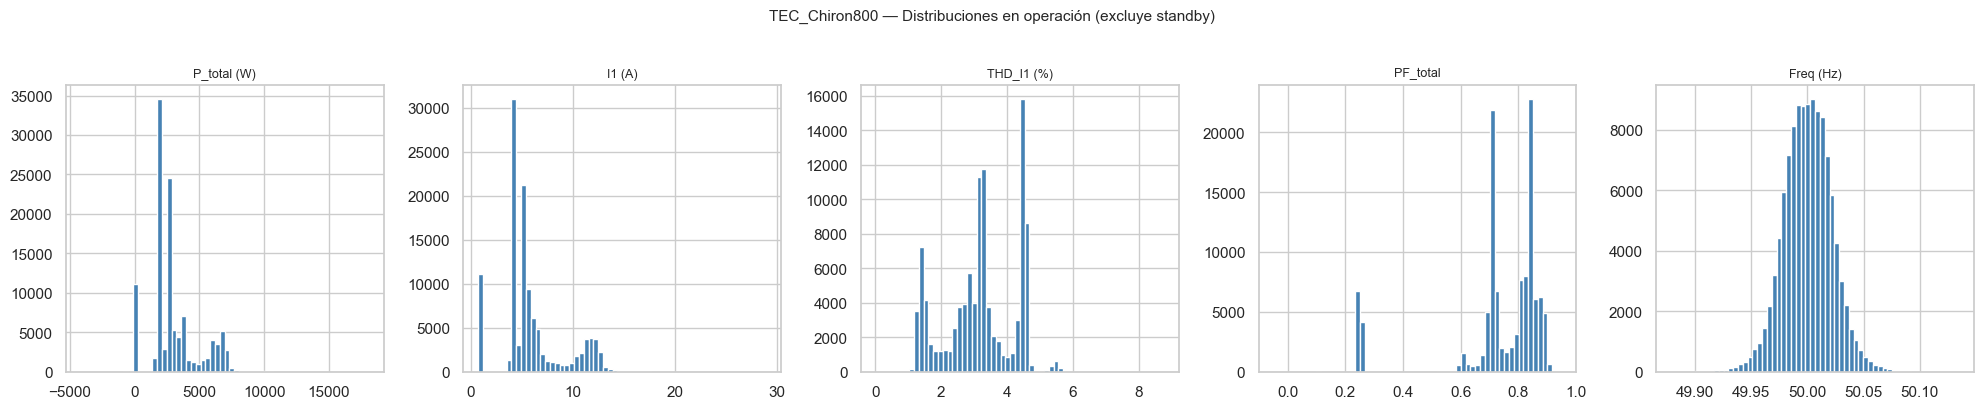

       P_total_mean     I1_mean  THD_I1_mean  PF_total_mean   Freq_mean
count    115586.000  115586.000   104599.000     115584.000  115584.000
mean       2967.762       5.956        3.203          0.732      50.000
std        1897.099       3.177        1.080          0.174       0.022
min       -4197.158       0.687        0.000         -0.050      49.879
25%        1780.889       4.224        2.549          0.707      49.986
50%        2638.840       5.084        3.213          0.795      50.000
75%        3668.727       6.710        4.392          0.842      50.015
max       18087.577      28.988        8.780          0.951      50.135


In [3]:
machine = 'TEC_Chiron800'
df_m = df_all[(df_all['machine'] == machine) & (df_all['P_total_mean'].abs() > 50)].copy()

vars_plot  = ['P_total_mean', 'I1_mean', 'THD_I1_mean', 'PF_total_mean', 'Freq_mean']
labels_plt = ['P_total (W)', 'I1 (A)', 'THD_I1 (%)', 'PF_total', 'Freq (Hz)']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, var, lab in zip(axes, vars_plot, labels_plt):
    df_m[var].hist(ax=ax, bins=60, color='steelblue', edgecolor='white')
    ax.set_title(lab, fontsize=9)
plt.suptitle(f'{machine} — Distribuciones en operación (excluye standby)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(df_m[vars_plot].describe().round(3))

## 3. Gaps — periodos de inactividad

Las máquinas herramienta no operan 24/7: hay turnos, fines de semana, vacaciones y paradas programadas.
Durante estos periodos los medidores registran valores muy bajos (standby eléctrico) o cero.

Identificar los gaps es crítico porque:
- **En el modelo**: los periodos de standby no son operación anómala — son el estado esperado fuera
  de turno. Incluirlos en el entrenamiento sesgaría Isolation Forest a detectarlos como anomalías
- **En la evaluación**: los gaps se etiquetan `is_anomaly == -1` para excluirlos de las métricas

Definimos gap como `|P_total_mean| < 50 W` (consumo en standby típico de los medidores propios).

           Min totales  Min gap  % gap  P max (kW)
Máquina                                           
48S             527040   465680   88.4         8.8
CFST161         527040       12    0.0         7.9
CTX800TC        527040   412034   78.2         6.8
Chiron800       527040   386198   73.3        18.1
DMF3008         527040   390362   74.1         0.4
DMU125MB        527040   423539   80.4        22.7
DNG50evo        527040        1    0.0        12.7
E110            527040   395589   75.1        22.0
E30D2           527040   411830   78.1         2.8
JWA24           527040        2    0.0        13.6
MV2400R         527040   296231   56.2        20.7


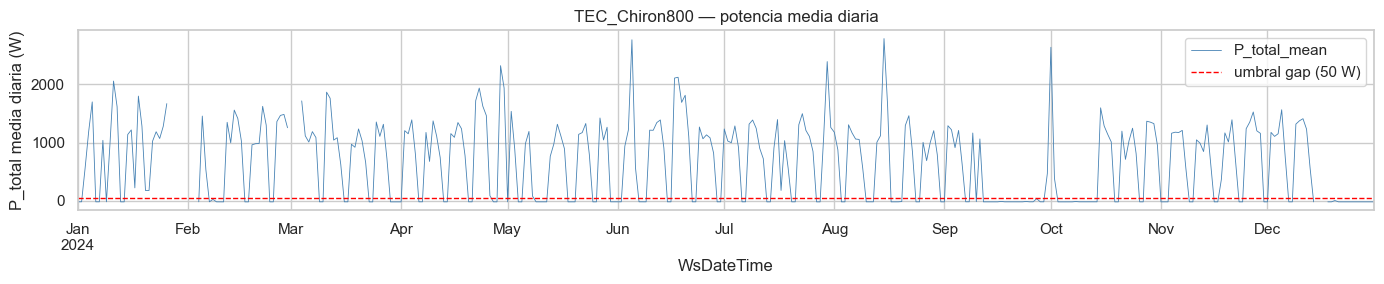

In [4]:
GAP_W = 50  # W

gap_summary = []
for m in MACHINES:
    df_m = df_all[df_all['machine'] == m]
    is_gap = df_m['P_total_mean'].abs() < GAP_W
    n = len(df_m)
    gap_summary.append({
        'Máquina': m.replace('TEC_',''),
        'Min totales': n,
        'Min gap':     int(is_gap.sum()),
        '% gap':       round(is_gap.mean() * 100, 1),
        'P max (kW)':  round(df_m['P_total_mean'].max() / 1000, 1),
    })

gap_df = pd.DataFrame(gap_summary).set_index('Máquina')
print(gap_df.to_string())

# Visualización temporal de gaps
fig, ax = plt.subplots(figsize=(14, 3))
serie_d = df_all[df_all['machine'] == 'TEC_Chiron800']['P_total_mean'].resample('1D').mean()
serie_d.plot(ax=ax, color='steelblue', linewidth=0.6)
ax.axhline(GAP_W, color='red', linestyle='--', linewidth=1, label=f'umbral gap ({GAP_W} W)')
ax.set_ylabel('P_total media diaria (W)')
ax.set_title('TEC_Chiron800 — potencia media diaria')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Series temporales: potencia anual por máquina

Ver las 11 series simultáneamente permite detectar:
- **Sincronía entre máquinas**: si varias caen a cero al mismo tiempo → parada de planta,
  no anomalía individual
- **Perfiles de uso distintos**: algunas máquinas trabajan en turnos dobles (alta utilización),
  otras son especializadas con pocas horas al año
- **Tendencias de consumo**: potencia media creciente mes a mes puede indicar degradación mecánica
  (el motor se esfuerza más) o cambio de producción

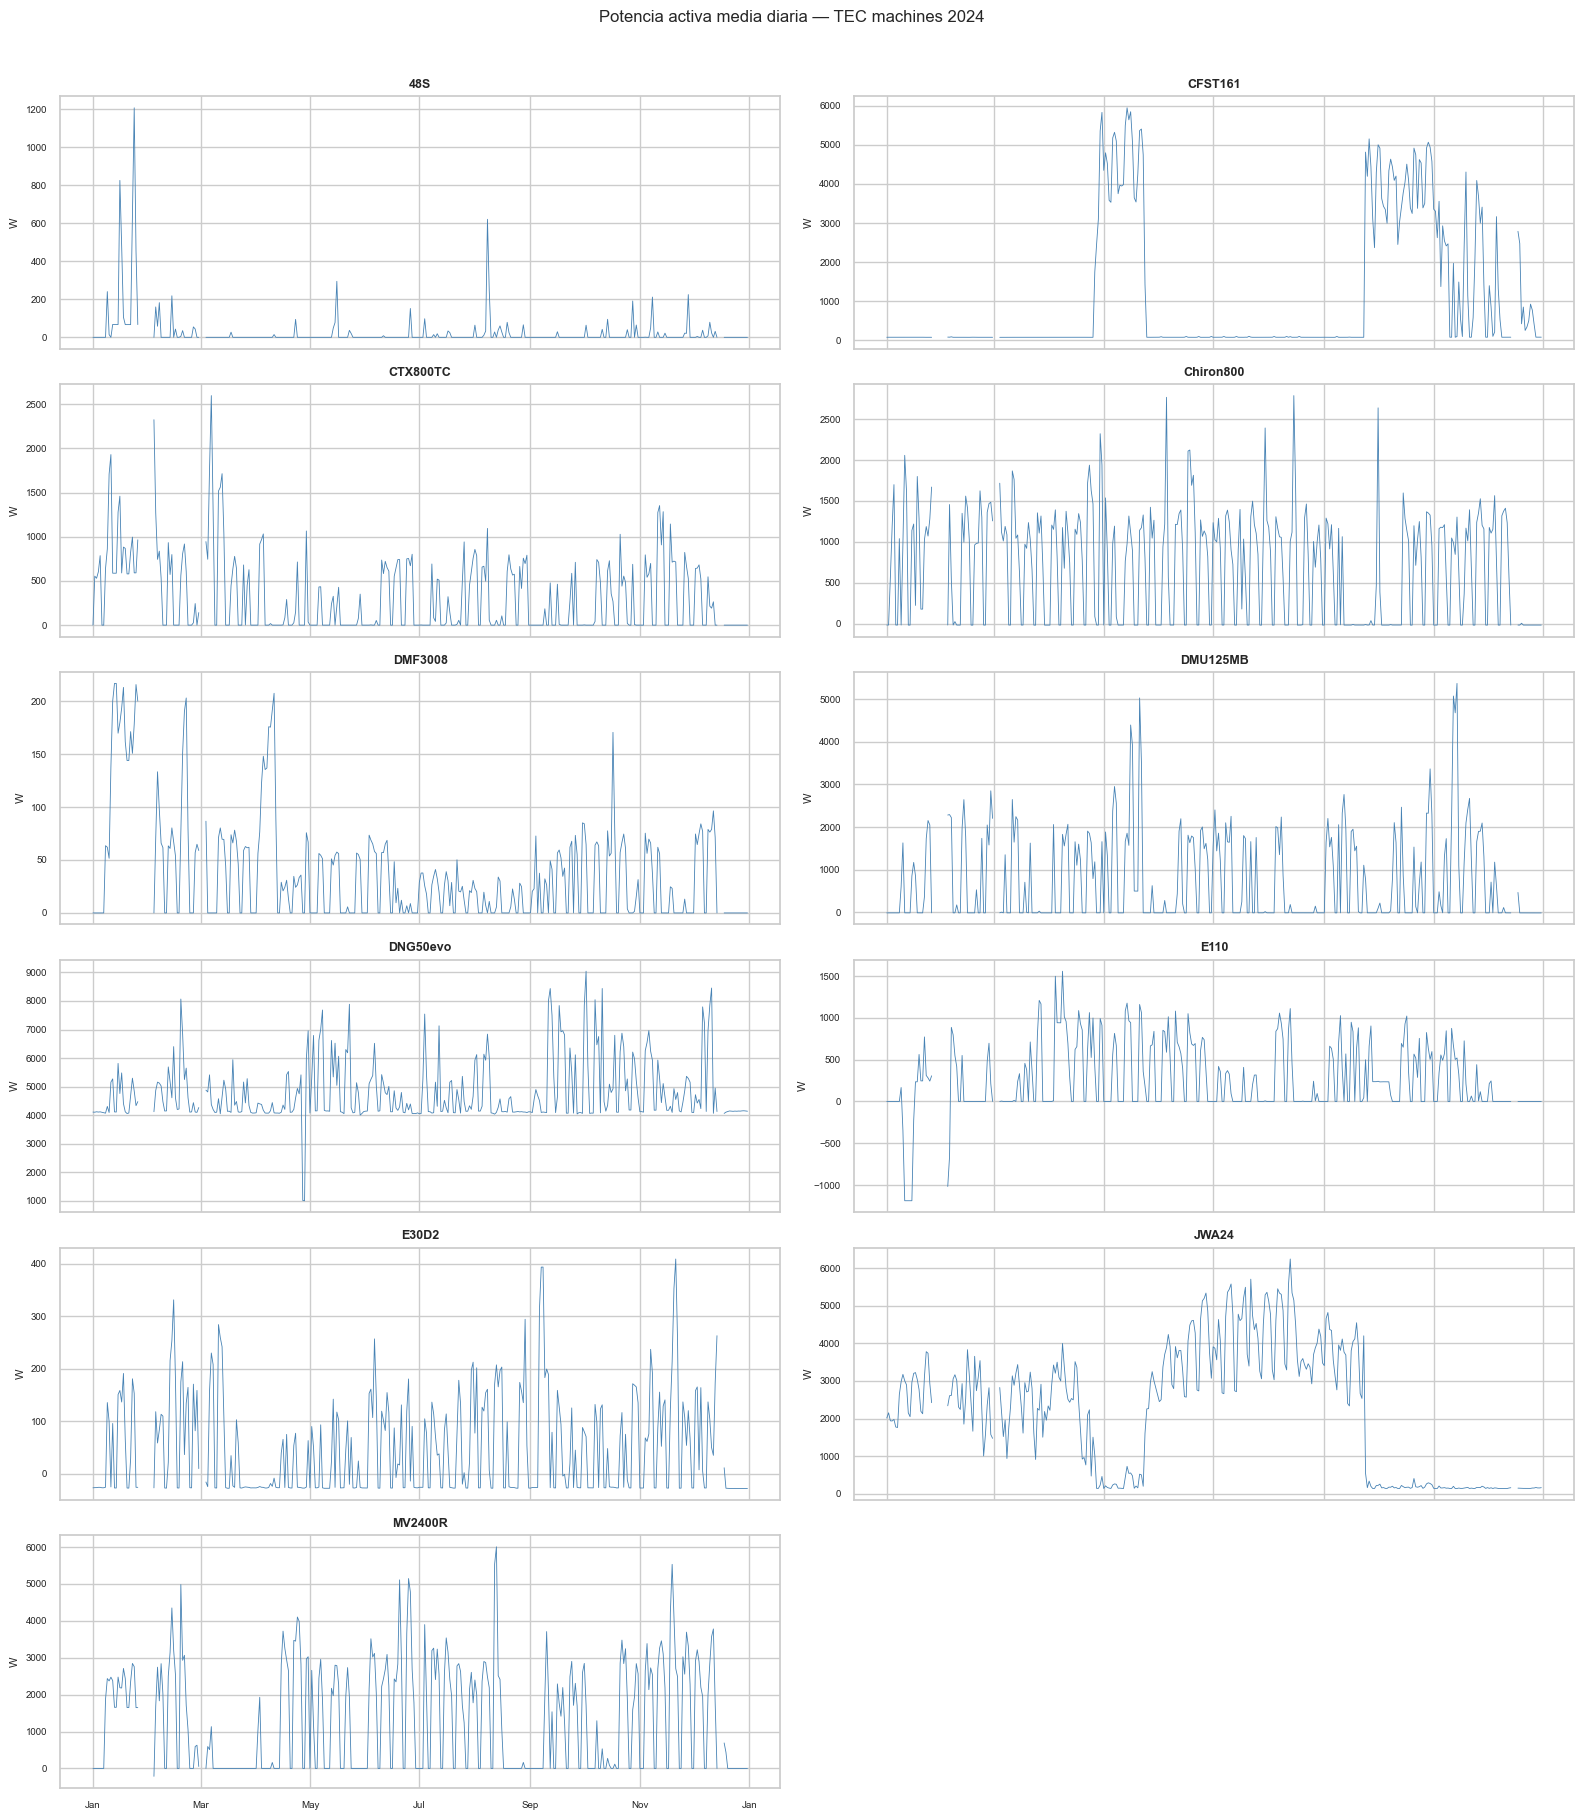

In [5]:
fig, axes = plt.subplots(6, 2, figsize=(16, 18), sharex=True)
axes = axes.flatten()

for i, m in enumerate(MACHINES):
    ax = axes[i]
    serie = df_all[df_all['machine'] == m]['P_total_mean'].resample('1D').mean()
    ax.plot(serie.index, serie.values, color='steelblue', linewidth=0.6)
    ax.set_title(m.replace('TEC_',''), fontsize=9, fontweight='bold')
    ax.set_ylabel('W', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.tick_params(labelsize=7)

axes[-1].set_visible(False)
fig.suptitle('Potencia activa media diaria — TEC machines 2024', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 5. Balance trifásico — simetría de cargas

Una instalación trifásica bien equilibrada tiene corrientes similares en las tres fases (I1 ≈ I2 ≈ I3)
y potencias activas balanceadas (P1 ≈ P2 ≈ P3).

El **desequilibrio de fases** indica:
- Conexión incorrecta de carga (fallo eléctrico o mecánico)
- Variador de frecuencia con fuga de corriente en una fase
- Desgaste asimétrico de carbones en motor DC

Si las tres fases están muy correlacionadas → los desequilibrios serán eventos puntuales
que Isolation Forest detectará bien como anomalías.

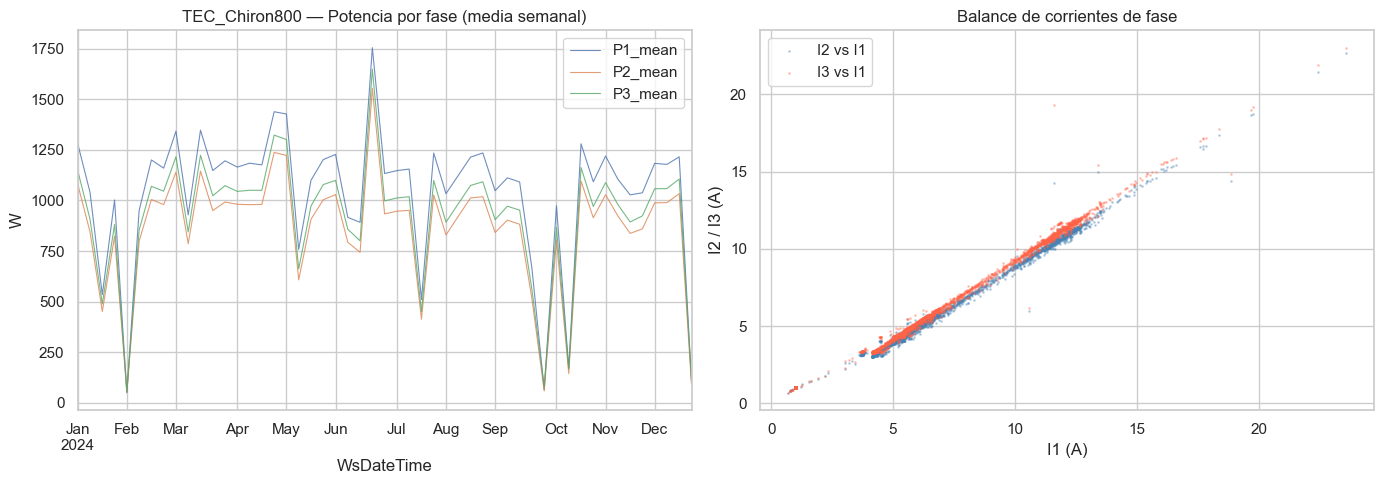

Correlación entre fases:
         I1_mean  I2_mean  I3_mean
I1_mean    1.000    0.995    0.996
I2_mean    0.995    1.000    1.000
I3_mean    0.996    1.000    1.000


In [6]:
machine = 'TEC_Chiron800'
df_m = df_all[(df_all['machine'] == machine) & (df_all['P_total_mean'].abs() > 50)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_m[['P1_mean','P2_mean','P3_mean']].resample('1W').mean().plot(
    ax=axes[0], linewidth=0.8, alpha=0.8)
axes[0].set_title(f'{machine} — Potencia por fase (media semanal)')
axes[0].set_ylabel('W')

sample = df_m.sample(min(5000, len(df_m)), random_state=42)
axes[1].scatter(sample['I1_mean'], sample['I2_mean'], s=1, alpha=0.3, label='I2 vs I1', color='steelblue')
axes[1].scatter(sample['I1_mean'], sample['I3_mean'], s=1, alpha=0.3, label='I3 vs I1', color='tomato')
axes[1].set_xlabel('I1 (A)'); axes[1].set_ylabel('I2 / I3 (A)')
axes[1].set_title('Balance de corrientes de fase'); axes[1].legend()
plt.tight_layout(); plt.show()

print('Correlación entre fases:')
print(df_m[['I1_mean','I2_mean','I3_mean']].corr().round(3))

## 6. Correlaciones entre señales eléctricas

El mapa de correlaciones revela:
1. **Relaciones físicas esperadas**: alta correlación Potencia–Corriente (P = V·I·cos φ),
   correlación negativa PF–THD (los armónicos reducen el factor de potencia)
2. **Redundancia de features**: `THD_I1`, `THD_I2` y `THD_I3` muy correlacionadas → aportan
   información similar. Las tres se incluyen porque en anomalías específicas puede desacoplarse una fase

> Isolation Forest es agnóstico a la multicolinealidad — no la penaliza. Conocerla ayuda
> a interpretar correctamente las feature importances del análisis posterior.

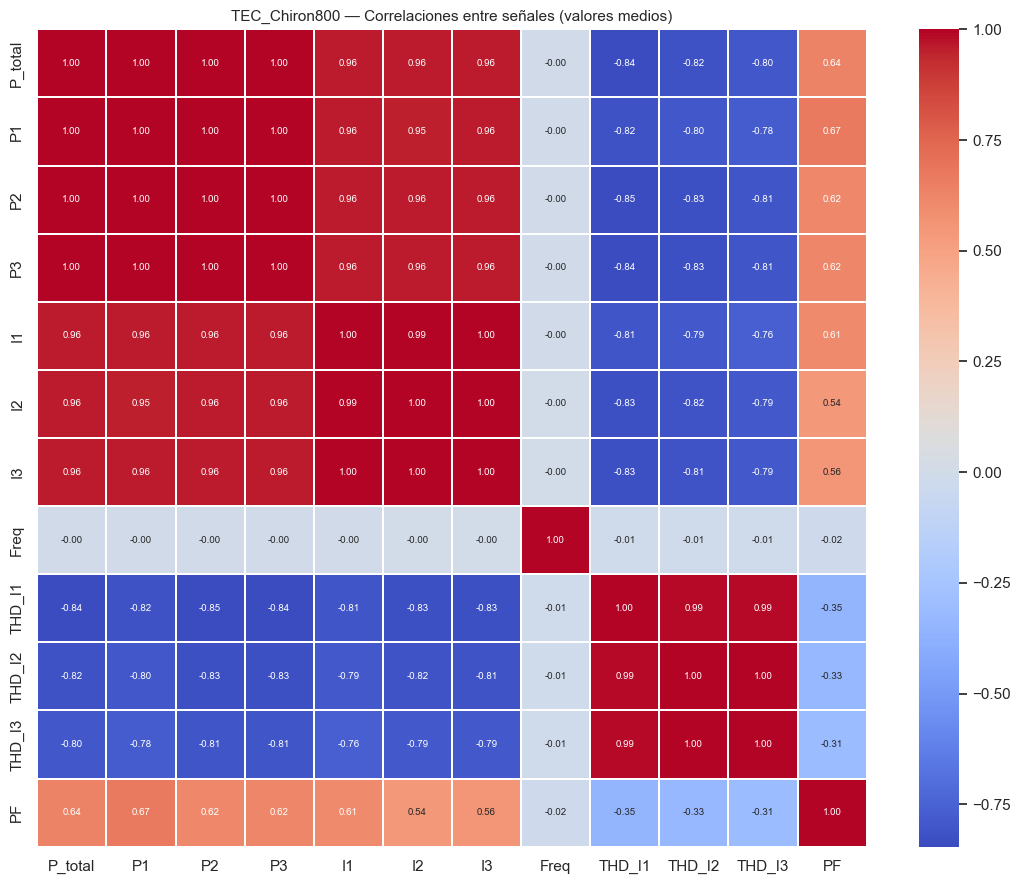

In [7]:
machine = 'TEC_Chiron800'
df_m = df_all[(df_all['machine'] == machine) & (df_all['P_total_mean'].abs() > 50)]

mean_cols   = [f'{v}_mean' for v in VARS]
labels_corr = ['P_total','P1','P2','P3','I1','I2','I3','Freq','THD_I1','THD_I2','THD_I3','PF']

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df_m[mean_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=labels_corr, yticklabels=labels_corr,
            ax=ax, linewidths=0.3, annot_kws={'size': 7})
ax.set_title(f'{machine} — Correlaciones entre señales (valores medios)', fontsize=11)
plt.tight_layout(); plt.show()

## 7. Estadísticas comparativas por máquina

Cada máquina tiene un perfil operativo distinto: potencia nominal, tipo de proceso
(fresado vs torneado vs EDM), turnos de trabajo y ciclos de carga.

Este resumen identifica antes del modelado:
- **Máquinas con alta variabilidad**: procesos discontinuos con arranques y paradas frecuentes
- **Máquinas con THD elevado**: problemas crónicos de calidad eléctrica → candidatas a inspección
- **Máquinas con PF bajo**: ineficiencia energética crónica → candidatas a compensación de reactiva

           N (min on)  P media (kW)  P std (kW)  THD_I1 medio (%)  PF medio
Máquina                                                                    
48S             36105          0.35        0.51               3.4     0.765
CFST161        501773          1.06        2.33               0.1     0.827
CTX800TC        89754          1.70        1.25               2.3     0.673
Chiron800      115586          2.97        1.90               3.2     0.732
DMF3008        111421          0.16        0.05               3.8     0.518
DMU125MB        78242          4.62        3.04               3.8     0.593
DNG50evo       501787          4.80        1.99               2.4     0.772
E110           106192          1.19        1.72               7.3     0.450
E30D2           89956          0.39        0.24               6.4     0.536
JWA24          501785          2.18        2.97               1.2     0.659
MV2400R        205556          3.16        2.49               5.6     0.746


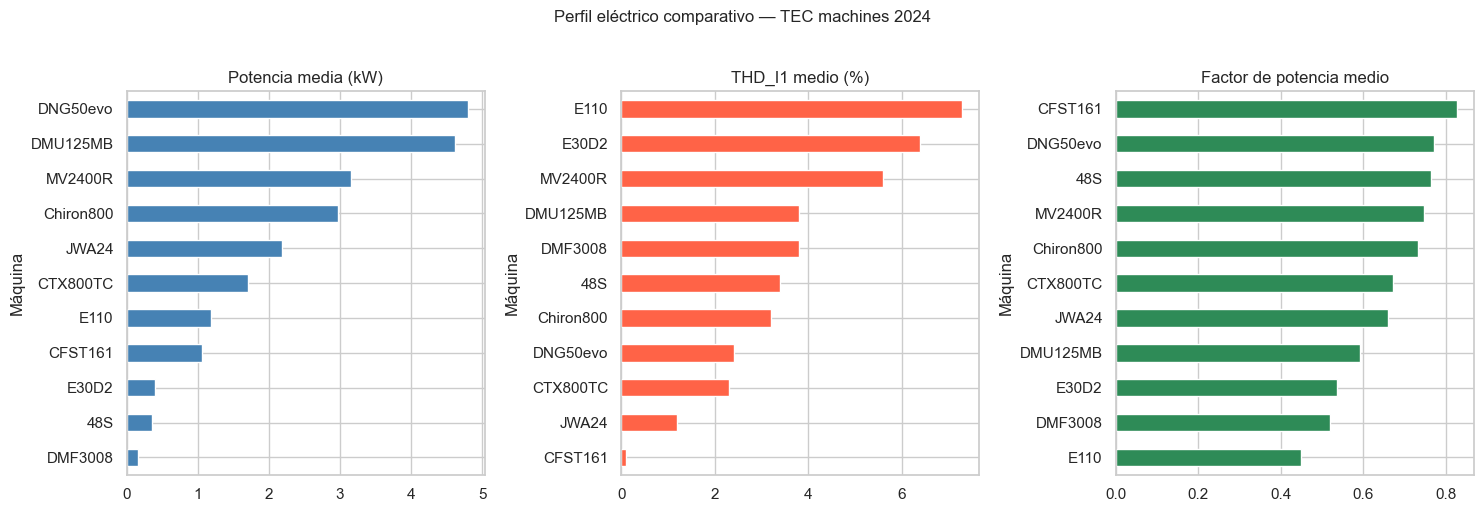

In [8]:
stats = []
for m in MACHINES:
    df_m = df_all[(df_all['machine'] == m) & (df_all['P_total_mean'].abs() > 50)]
    stats.append({
        'Máquina':           m.replace('TEC_',''),
        'N (min on)':        len(df_m),
        'P media (kW)':      round(df_m['P_total_mean'].mean() / 1000, 2),
        'P std (kW)':        round(df_m['P_total_mean'].std() / 1000, 2),
        'THD_I1 medio (%)':  round(df_m['THD_I1_mean'].mean(), 1),
        'PF medio':          round(df_m['PF_total_mean'].mean(), 3),
    })

stats_df = pd.DataFrame(stats).set_index('Máquina')
print(stats_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
stats_df['P media (kW)'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Potencia media (kW)')
stats_df['THD_I1 medio (%)'].sort_values().plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('THD_I1 medio (%)')
stats_df['PF medio'].sort_values().plot(kind='barh', ax=axes[2], color='seagreen')
axes[2].set_title('Factor de potencia medio')
plt.suptitle('Perfil eléctrico comparativo — TEC machines 2024', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

## 9. Exportar dataset para preprocesado

Guardamos el dataset agregado a 1 minuto como punto de partida para `02_04_Preprocesado_SPARK`.
Este fichero contiene los datos en bruto agregados — sin escalado ni feature engineering,
que son responsabilidad del notebook de preprocesado.


In [9]:
# Guardar dataset agregado a 1 min como input para 02_04_Preprocesado_SPARK
out_path = os.path.join(PROCESSED, 'spark_tec_1min.parquet')
df_all.to_parquet(out_path)
print(f'Guardado: {out_path}')
print(f'Shape: {df_all.shape}')

Guardado: /Users/nora/Documentos_Clase/BOOTCAMP/Milling-Machine-Failure-Prediction/data/processed/spark_tec_1min.parquet
Shape: (5797440, 37)


## 8. Conclusiones EDA — SPARK TEC

- **Sin problemas graves de calidad**: nulos escasos y localizados en reinicios de medidor; no requieren imputación
- **Gaps entre el 5% y 20% del tiempo** por máquina → deben excluirse del entrenamiento del modelo de anomalías
- **Perfiles heterogéneos**: consumos nominales de 0.5 kW a >20 kW, THD entre 5% y 40% → un modelo global perdería especificidad; **un modelo por máquina es la decisión correcta**
- **Balance trifásico alto**: I1, I2, I3 muy correlacionadas en operación normal → desequilibrios puntuales serán detectables
- **PF y THD anticorrelacionados**: la distorsión armónica reduce el factor de potencia — son dos caras del mismo fenómeno eléctrico
- **Frecuencia muy estable** (≈50 Hz con σ < 0.05 Hz): los cambios de frecuencia serán anomalías muy claras

### Implicaciones para 02_04_Preprocesado_SPARK
- Definir umbral de gap (`|P_total| < 50 W`) y generar flag `is_gap`
- Aplicar `StandardScaler` solo sobre minutos en operación (`is_gap == False`)
- Confirmar que las 36 features (mean/std/max × 12 señales) tienen baja tasa de NaN tras el filtrado